# Truncated Multivariate Normal Distribution


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from arviz import convert_to_inference_data, summary
from IPython.display import display
from scipy.linalg import solve
from scipy.stats import gaussian_kde, norm
from tqdm import trange

In [2]:
def mcmc_stats(runs, burnin=0, chain=4, prob=0.95, param_string=None, isvariance=True):
    """
    Posterior statistics

    Inputs
    runs         --- Monte Carlo sample
    burnin       --- the number of runs in the burnin stage
    chain        --- the number of chains used for convergence diagnostics
    prob         --- the posterior probability for interval estimation
    param_string --- the list of parameter names
    isvariance   ---- True if the variance is included

    Outputs
    posterior_statistics ---  table of posterior statistics (Pandas datafarme)
    """
    if runs.shape[0] < burnin:
        raise ValueError('You need to reduce the number of draws to be discarded as burnin.')
    draw = (runs.shape[0] - burnin) // chain
    if runs.shape[0] != burnin + draw * chain:
        raise ValueError('The number of draws must be divided by the number of chains.')
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1])]
    traces = convert_to_inference_data(np.stack([runs[burnin:, i].reshape((chain, draw)) \
                                                 for i in range(runs.shape[1])], axis=2))
    posterior_statistics = summary(traces, hdi_prob=prob)
    posterior_statistics.index = param_string
    return posterior_statistics

In [3]:
def mcmc_plots(runs, burnin=0, param_string=None, isvariance=True):
    """
    Posterior plots

    Inputs
    runs          --- Monte Carlo sample
    burnin        --- the number of runs in the burnin stage
    isvariance   ---- True if the variance is included

    Outputs
    kde_x         --- grid
    kde_posterior --- kernel density estimation
    """
    grid = 250
    k = runs.shape[1]
    kde_x = np.zeros((grid, k))
    kde_posterior = np.zeros((grid, k))
    if isvariance:
        num_b = k - 1
    else:
        num_b = k
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1])]
    fig, ax = plt.subplots(k, 2, num=1, figsize=(8, 1.5*k), facecolor='w')
    for index in range(k):
        mc_trace = runs[burnin:, index]
        if index < num_b:
            x_min = mc_trace.min() - 0.2 * np.abs(mc_trace.min())
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        else:
            x_min = 0.0
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        posterior = gaussian_kde(mc_trace).evaluate(x)
        ax[index, 0].plot(mc_trace, linewidth=0.1)
        ax[index, 0].set_xlim(1, draws)
        ax[index, 0].set_ylabel(y_label)
        ax[index, 1].plot(x, posterior)
        ax[index, 1].set_xlim(x_min, x_max)
        ax[index, 1].set_ylim(0, 1.1*posterior.max())
        ax[index, 1].set_ylabel('Density')
        kde_x[:, index] = x
        kde_posterior[:, index] = posterior
    ax[-1, 0].set_xlabel('Random Sequence')
    ax[-1, 1].set_xlabel('Posterior Distribution')
    plt.tight_layout()
    plt.show
    return kde_x, kde_posterior

## Gibbs sampler for $\text{Normal}^{+}(\mu,\Sigma)$

Suppose $x$ is a $k$-dimensional random vector following a multivariate normal distribution truncated to be positive (i.e., $x_{1}>0, \dots, x_{k}>0$), which is denoted by $\text{Normal}^{+}(\mu,\Sigma)$.

### 1. Full conditional distribution

Consider the following partitions:

$$
    x = \begin{bmatrix} x_{-j} \\ x_{j} \end{bmatrix}, \quad
    \mu = \begin{bmatrix} \mu_{-j} \\ \mu_{j} \end{bmatrix}, \quad
    \Sigma = \begin{bmatrix}
                 \Sigma_{-j} & \sigma_{-j}^{\intercal} \\
                 \sigma_{-j} & \sigma_{j}^{2} \\
               \end{bmatrix}.
$$

Then the full conditional distribution of $x_{j}$ given $x_{j} > 0$ and $x_{-j} = (x_{1},\dots,x_{j-1},x_{j+1},\dots,x_{k})$ is

$$
\begin{split}
      & f(x_{j}|x_{j}>0,x_{-j}) \propto \exp\left[-\frac{(x_{j} - \mu_{j}^*(x_{-j}))^{2}}
        {2\sigma_{j}^{2*}}\right]\mathbb{1}_{(0,\infty)}(x_{j}), \\
      & \mu_{j}^*(x_{-j}) = \mu_{j} + \sigma_{-j}^{\intercal}\Sigma_{-j}^{-1}(x_{-j}-\mu_{-j}),\quad \sigma_{j}^{2*} = \sigma_{j}^{2}-\sigma_{-j}^{\intercal}\Sigma_{-j}^{-1}\sigma_{-j}.
\end{split}
$$

### 2. Gibbs sampling algorithm

$$
\begin{split}
    x_{1}^{(r)} &\leftarrow \mathrm{Normal}^+(\mu_{1}^*(x_{2}^{(r-1)},\ldots,x_{k}^{(r-1)}),\sigma_{1}^{2*}), \\
    x_{2}^{(r)} & \leftarrow \mathrm{Normal}^+(\mu_{2}^*(x_{1}^{(r)},x_3^{(r-1)},\ldots,x_{k}^{(r-1)}),\sigma_{2}^{2*}), \\
                & \vdots \\
    x_{k}^{(r)} &\leftarrow \mathrm{Normal}^+(\mu_{k}^*(x_{1}^{(r)},\ldots,x_{k-1}^{(r)}),\sigma_{k}^{2*}).
\end{split}
$$


In [4]:
def gibbs_truncated_normal(mu, Sigma, burnin=1000, draws=10000, param_string=None, rng=None):
    if rng == None:
        rng = np.ramdom.default_rng(seed=1234)
    iterations = burnin + draws
    conditional_mean1 = []
    conditional_mean2 = []
    conditional_sd = []
    k = len(mu)
    for i in range(k):
        idx = np.delete(np.arange(k), i)
        Sigma_ii = Sigma[idx, :][:, idx]
        sigma_i = Sigma[idx, i]
        sigma2_i = Sigma[i, i]
        mu_i = mu[i]
        mu_ii = np.delete(mu, i)
        mu2 = solve(Sigma_ii, sigma_i)
        mu1 = mu_i - mu2 @ mu_ii
        conditional_mean1.append(mu1)
        conditional_mean2.append(mu2)
        conditional_sd.append(np.sqrt(sigma2_i - mu2 @ sigma_i))
    runs = np.empty((iterations, k))
    x_t = np.ones(k)
    for it in trange(iterations):
        for i in range(k):
            mean_x = conditional_mean1[i] + conditional_mean2[i] @ np.delete(x_t, i)
            sd_x = conditional_sd[i]
            prob = norm.cdf(0.0, loc=mean_x, scale=sd_x)
            u = rng.uniform(low=prob)
            x_t[i] = norm.ppf(u, loc=mean_x, scale=sd_x)
        runs[it, :] = x_t
    return runs

In [5]:
mu = np.array([0.0, 1.0, 2.0])
Sigma = np.array([[2, -1, -1], [-1, 1.5, 0.5], [-1, 0.4, 1.5]])
burnin = 5000
draws = 50000
rng = np.random.default_rng(seed=99)
runs = gibbs_truncated_normal(mu, Sigma, burnin=burnin, draws=draws, rng=rng)

100%|██████████████████████████████████████████████████████████████████████████| 55000/55000 [00:12<00:00, 4386.65it/s]


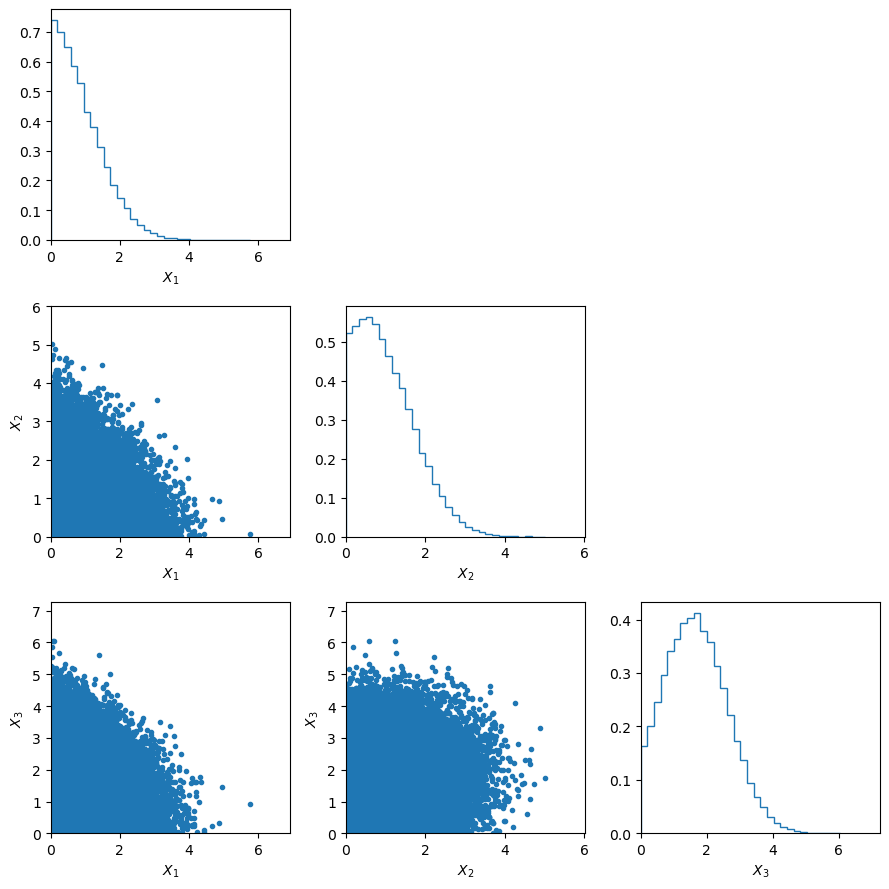

In [6]:
k = len(mu)
fig1, ax1 = plt.subplots(k, k, num=1, figsize=(3*k, 3*k), facecolor='w')
x_min = 0.0
y_min = 0.0
for i in range(k):
    mc_y = runs[:, i]
    y_max = mc_y.max() + 0.2 * np.abs(mc_y.max())
    for j in range(k):
        if j > i:
            ax1[i, j].axis('off')
        else:
            mc_x = runs[:, j]
            x_max = mc_x.max() + 0.2 * np.abs(mc_x.max())
            ax1[i, j].set_xlabel(f'$X_{{{j+1}}}$')
            ax1[i, j].set_xlim(x_min, x_max)
            if j == i:
                ax1[i, j].hist(mc_x, density=True, histtype='step', bins=30)
            else:
                ax1[i, j].plot(mc_x, mc_y, '.')
                ax1[i, j].set_ylabel(f'$X_{{{i+1}}}$')
                ax1[i, j].set_ylim(y_min, y_max)
plt.tight_layout()
plt.show()